Model Accuracy: 0.743

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.19      0.18       297
           1       0.86      0.84      0.85      1703

    accuracy                           0.74      2000
   macro avg       0.51      0.52      0.51      2000
weighted avg       0.75      0.74      0.75      2000



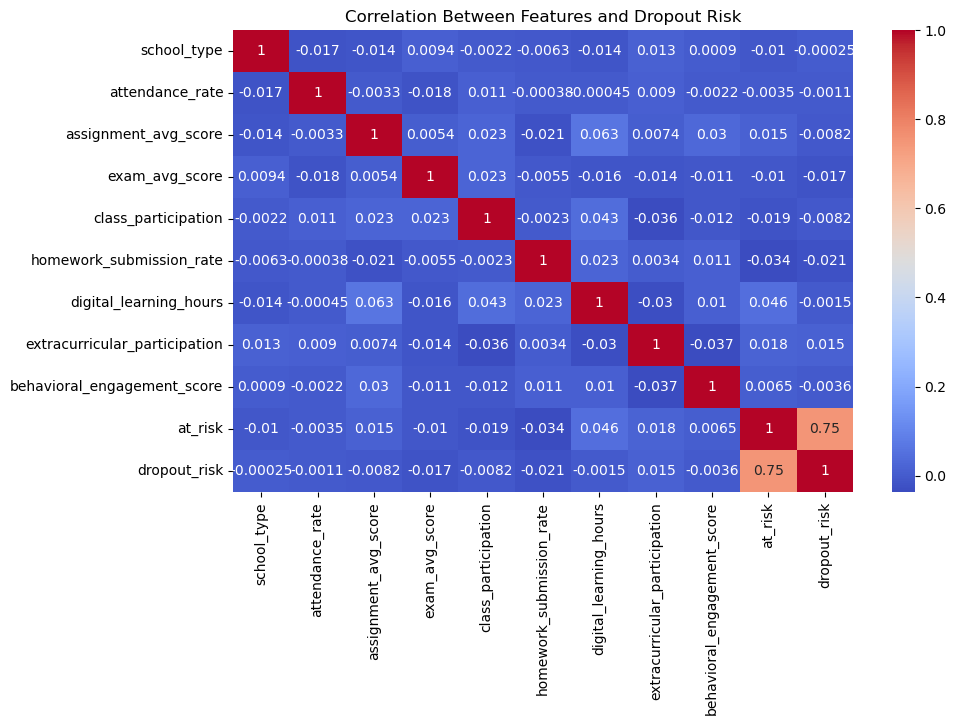

Feature Importance:

homework_submission_rate         0.144747
assignment_avg_score             0.136630
extracurricular_participation    0.129651
class_participation              0.128153
exam_avg_score                   0.124422
behavioral_engagement_score      0.116439
digital_learning_hours           0.111906
school_type                      0.080466
attendance_rate                  0.027586
dtype: float64


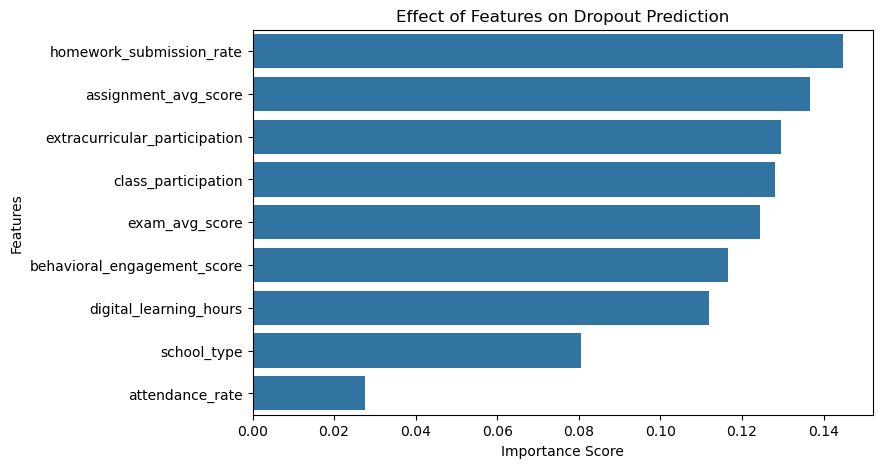

In [10]:
# ---------------------------------------------
# 1. Import Libraries
# ---------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------------------------
# 2. Load Dataset
# ---------------------------------------------
df = pd.read_csv("cleaned_student_dataset.csv")

# ---------------------------------------------
# 3. Convert Target Variable
# ---------------------------------------------
df['dropout_risk'] = (df['at_risk'] >= 5).astype(int)

# ---------------------------------------------
# 4. Define Features and Target
# ---------------------------------------------
X = df.drop(columns=['at_risk','dropout_risk'])
y = df['dropout_risk']


# ---------------------------------------------
# 7. Train Decision Tree Model
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ---------------------------------------------
# 5. Model Evaluation
# ---------------------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---------------------------------------------
# 6. Correlation Analysis
# ---------------------------------------------
correlation = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Between Features and Dropout Risk")
plt.show()

# ---------------------------------------------
# 8. Feature Importance
# ---------------------------------------------
importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

print("Feature Importance:\n")
print(importance)

# ---------------------------------------------
# 9. Visualize Feature Importance
# ---------------------------------------------
plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=importance.index)
plt.title("Effect of Features on Dropout Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()